In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile, os
import pandas as pd
import os
import torchaudio
import torch
from transformers import Wav2Vec2Model, Wav2Vec2Processor
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from tqdm import tqdm
from transformers import HubertModel

Завантаження датасету:

In [4]:
zip_path = '/content/drive/MyDrive/archive.zip'
extract_path = '/content/timit'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

Перевірка структури:

In [ ]:
for root, dirs, files in os.walk('/content/timit'):
    level = root.replace('/content/timit', '').count(os.sep)
    if level < 4:
        print('  ' * level + os.path.basename(root) + '/')
        if level == 3:
            sample_files = [f for f in files[:3]]
            for f in sample_files:
                print('  ' * (level+1) + f)

timit/
  data/
    TRAIN/
      DR1/
      DR2/
      DR4/
      DR7/
      DR6/
      DR3/
      DR8/
      DR5/
    TEST/
      DR1/
      DR2/
      DR4/
      DR7/
      DR6/
      DR3/
      DR8/
      DR5/


Зчитування CSV-файлів з інформацією про структуру датасету:

In [8]:
train_csv = pd.read_csv('/content/timit/train_data.csv')
test_csv = pd.read_csv('/content/timit/test_data.csv')

BASE_DIR = '/content/timit/data'

train_audio = train_csv[train_csv['is_audio'] == True].reset_index(drop=True)
test_audio = test_csv[test_csv['is_audio'] == True].reset_index(drop=True)

print(f"Train аудіо файлів: {len(train_audio)}")
print(f"Test аудіо файлів: {len(test_audio)}")
print(train_audio['path_from_data_dir'].iloc[0])

Train аудіо файлів: 9240
Test аудіо файлів: 3360
TRAIN/DR4/MMDM0/SI681.WAV.wav


Формування списків train_pairs та test_pairs для подальшої обробки:

In [9]:
def get_wav_phn_pairs(audio_df, base_dir):
    pairs = []
    for _, row in audio_df.iterrows():
        wav_path = os.path.join(base_dir, row['path_from_data_dir'])

        wav_name = row['filename']
        base_name = wav_name.replace('.WAV.wav', '').replace('.wav', '')
        phn_name = base_name + '.PHN'

        phn_path = os.path.join(
            base_dir,
            row['path_from_data_dir'].replace(wav_name, phn_name)
        )

        if os.path.exists(wav_path) and os.path.exists(phn_path):
            pairs.append({'wav': wav_path, 'phn': phn_path})

    return pairs

train_pairs = get_wav_phn_pairs(train_audio, BASE_DIR)
test_pairs = get_wav_phn_pairs(test_audio, BASE_DIR)

print(f"Train пар знайдено: {len(train_pairs)}")
print(f"Test пар знайдено: {len(test_pairs)}")

print("\nПриклад:")
print("WAV:", train_pairs[0]['wav'])
print("PHN:", train_pairs[0]['phn'])
print("WAV існує:", os.path.exists(train_pairs[0]['wav']))
print("PHN існує:", os.path.exists(train_pairs[0]['phn']))

Train пар знайдено: 4620
Test пар знайдено: 1680

Приклад:
WAV: /content/timit/data/TRAIN/DR4/MMDM0/SI681.WAV.wav
PHN: /content/timit/data/TRAIN/DR4/MMDM0/SI681.PHN
WAV існує: True
PHN існує: True


Кожна фонема описана трьома значеннями: номер початкового семпла, номер кінцевого семпла та назва фонеми.

Ця функція зчитує файл рядок за рядком, витягує ці значення та приводить назву фонеми до нижнього регістру для уніфікації.

In [11]:
def parse_phn_file(phn_path):
    phonemes = []
    with open(phn_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3:
                start, end, phone = int(parts[0]), int(parts[1]), parts[2].lower()
                phonemes.append((start, end, phone))
    return phonemes

phn = parse_phn_file(train_pairs[0]['phn'])
print("Перші 5 фонем:", phn[:5])

Перші 5 фонем: [(0, 1960, 'h#'), (1960, 2466, 'w'), (2466, 3480, 'ix'), (3480, 4000, 'dcl'), (4000, 5960, 's')]


Завантаження сирого аудіосигналу у вигляді тензора:

In [ ]:
waveform, sr = torchaudio.load(train_pairs[0]['wav'])
print(f"Shape: {waveform.shape}, Sample rate: {sr}")

Shape: torch.Size([1, 39936]), Sample rate: 16000


Ініціалізація SSL-моделі:

In [13]:
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
ssl_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")
ssl_model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
ssl_model = ssl_model.to(device)
print(f"Пристрій: {device}")

def extract_features(wav_path):
    waveform, sr = torchaudio.load(wav_path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != 16000:
        waveform = torchaudio.functional.resample(waveform, sr, 16000)

    audio = waveform.squeeze(0).numpy()

    inputs = processor(audio, sampling_rate=16000, return_tensors="pt")
    input_values = inputs.input_values.to(device)

    with torch.no_grad():
        outputs = ssl_model(input_values)

    features = outputs.last_hidden_state.squeeze(0).cpu()
    return features

feats = extract_features(train_pairs[0]['wav'])
print(f"Ознаки shape: {feats.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.weight             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Пристрій: cuda
Ознаки shape: torch.Size([124, 768])


Оскільки SSL-моделі видають ознаки з фіксованим кроком, потрібно привести часові мітки фонем з файлів .PHN до фреймів моделі.
Формування повного списку фонем та створення функції для мапінгу кожної секунди аудіо до конкретного ID фонеми:

In [14]:
ALL_PHONEMES = sorted(list(set(
    phone
    for pair in train_pairs + test_pairs
    for _, _, phone in parse_phn_file(pair['phn'])
)))
phoneme2id = {p: i for i, p in enumerate(ALL_PHONEMES)}
NUM_CLASSES = len(ALL_PHONEMES)
print(f"Унікальних фонем: {NUM_CLASSES}")
print(ALL_PHONEMES)

def get_frame_labels(phn_path, num_frames, hop=320):
    phonemes = parse_phn_file(phn_path)
    labels = []
    for i in range(num_frames):
        center = i * hop + hop // 2
        label = 0
        for start, end, phone in phonemes:
            if start <= center < end:
                label = phoneme2id.get(phone, 0)
                break
        labels.append(label)
    return torch.tensor(labels, dtype=torch.long)

feats = extract_features(train_pairs[0]['wav'])
labels = get_frame_labels(train_pairs[0]['phn'], feats.shape[0])
print(f"Фічі: {feats.shape}, Мітки: {labels.shape}")
print(f"Унікальні мітки у цьому файлі: {labels.unique()}")

Унікальних фонем: 61
['aa', 'ae', 'ah', 'ao', 'aw', 'ax', 'ax-h', 'axr', 'ay', 'b', 'bcl', 'ch', 'd', 'dcl', 'dh', 'dx', 'eh', 'el', 'em', 'en', 'eng', 'epi', 'er', 'ey', 'f', 'g', 'gcl', 'h#', 'hh', 'hv', 'ih', 'ix', 'iy', 'jh', 'k', 'kcl', 'l', 'm', 'n', 'ng', 'nx', 'ow', 'oy', 'p', 'pau', 'pcl', 'q', 'r', 's', 'sh', 't', 'tcl', 'th', 'uh', 'uw', 'ux', 'v', 'w', 'y', 'z', 'zh']
Фічі: torch.Size([124, 768]), Мітки: torch.Size([124])
Унікальні мітки у цьому файлі: tensor([ 1,  2,  9, 10, 11, 13, 17, 24, 27, 31, 32, 35, 38, 47, 48, 50, 51, 55,
        56, 57, 58, 60])


Створення Dataset та DataLoader:

In [15]:
class TIMITDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]
        features = extract_features(pair['wav'])
        labels = get_frame_labels(pair['phn'], features.shape[0])
        return features, labels

def collate_fn(batch):
    features, labels = zip(*batch)
    max_len = max(f.shape[0] for f in features)

    padded_features = torch.zeros(len(features), max_len, 768)
    padded_labels = torch.full((len(features), max_len), -100, dtype=torch.long)

    for i, (f, l) in enumerate(zip(features, labels)):
        padded_features[i, :f.shape[0]] = f
        padded_labels[i, :l.shape[0]] = l

    return padded_features, padded_labels

train_dataset = TIMITDataset(train_pairs)
test_dataset = TIMITDataset(test_pairs)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False,
                         collate_fn=collate_fn, num_workers=0)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train batches: 289, Test batches: 105


Побудова та налаштування класифікатора:

In [16]:
class PhonemeClassifier(nn.Module):
    def __init__(self, input_dim=768, num_classes=NUM_CLASSES):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)

classifier = PhonemeClassifier().to(device)
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=-100)

print(f"Параметрів моделі: {sum(p.numel() for p in classifier.parameters()):,}")

Параметрів моделі: 212,541


навчання моделі:

In [37]:
NUM_EPOCHS = 15
best_loss = float('inf')
train_losses = []

for epoch in range(NUM_EPOCHS):
    classifier.train()
    total_loss = 0

    for features, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        features = features.to(device)
        labels = labels.to(device)

        logits = classifier(features)
        loss = criterion(logits.permute(0, 2, 1), labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {avg_loss:.4f}")

Epoch 1/15: 100%|██████████| 289/289 [02:20<00:00,  2.05it/s]


Epoch 1/15 | Loss: 2.3333


Epoch 2/15: 100%|██████████| 289/289 [02:16<00:00,  2.12it/s]


Epoch 2/15 | Loss: 1.5649


Epoch 3/15: 100%|██████████| 289/289 [02:15<00:00,  2.13it/s]


...

Epoch 13/15 | Loss: 0.9721


Epoch 14/15: 100%|██████████| 289/289 [02:15<00:00,  2.14it/s]


Epoch 14/15 | Loss: 0.9602


Epoch 15/15: 100%|██████████| 289/289 [02:14<00:00,  2.14it/s]

Epoch 15/15 | Loss: 0.9450


In [ ]:
def compute_per(loader, model):
    model.eval()
    total_errors = 0
    total_frames = 0

    with torch.no_grad():
        for features, labels in tqdm(loader, desc="Evaluating"):
            features = features.to(device)
            logits = model(features)
            preds = logits.argmax(dim=-1).cpu()

            for pred_seq, label_seq in zip(preds, labels):
                mask = label_seq != -100
                pred_seq = pred_seq[mask]
                label_seq = label_seq[mask]

                errors = (pred_seq != label_seq).sum().item()
                total_errors += errors
                total_frames += len(label_seq)

    return total_errors / total_frames if total_frames > 0 else 1.0

per = compute_per(test_loader, classifier)
print(f"\nPER на тестовому наборі: {per:.4f} ({per*100:.2f}%)")

Evaluating: 100%|██████████| 105/105 [00:51<00:00,  2.02it/s]


PER на тестовому наборі: 0.2951 (29.51%)


Експерименти з HuBERT:

In [22]:
hubert = HubertModel.from_pretrained("facebook/hubert-base-ls960")
hubert.eval()
hubert = hubert.to(device)

def extract_features_hubert(wav_path):
    waveform, sr = torchaudio.load(wav_path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != 16000:
        waveform = torchaudio.functional.resample(waveform, sr, 16000)

    audio = waveform.squeeze(0)

    with torch.no_grad():
        outputs = hubert(audio.unsqueeze(0).to(device))

    return outputs.last_hidden_state.squeeze(0).cpu()

feats = extract_features_hubert(train_pairs[0]['wav'])
print(f"HuBERT ознаки: {feats.shape}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

HuBERT ознаки: torch.Size([124, 768])


In [23]:
def extract_features_layer(wav_path, model, layer_idx=-1):
    waveform, sr = torchaudio.load(wav_path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != 16000:
        waveform = torchaudio.functional.resample(waveform, sr, 16000)

    audio = waveform.squeeze(0)

    with torch.no_grad():
        outputs = model(
            audio.unsqueeze(0).to(device),
            output_hidden_states=True
        )

    hidden = outputs.hidden_states[layer_idx]
    return hidden.squeeze(0).cpu()

feats_layer6 = extract_features_layer(train_pairs[0]['wav'], hubert, layer_idx=6)
feats_layer12 = extract_features_layer(train_pairs[0]['wav'], hubert, layer_idx=12)
print(f"Шар 6: {feats_layer6.shape}")
print(f"Шар 12: {feats_layer12.shape}")

Шар 6: torch.Size([124, 768])
Шар 12: torch.Size([124, 768])


Запуск циклу: dataset → train → PER:

In [ ]:
def run_experiment(pairs_train, pairs_test, feature_fn, name, epochs=10):
    print(f"\n{'='*50}")
    print(f"ЕКСПЕРИМЕНТ: {name}")
    print(f"{'='*50}")

    class ExpDataset(Dataset):
        def __init__(self, pairs):
            self.pairs = pairs
        def __len__(self):
            return len(self.pairs)
        def __getitem__(self, idx):
            p = self.pairs[idx]
            features = feature_fn(p['wav'])
            labels = get_frame_labels(p['phn'], features.shape[0])
            return features, labels

    tr_loader = DataLoader(ExpDataset(pairs_train), batch_size=16,
                           shuffle=True, collate_fn=collate_fn, num_workers=0)
    te_loader = DataLoader(ExpDataset(pairs_test), batch_size=16,
                           shuffle=False, collate_fn=collate_fn, num_workers=0)

    model = PhonemeClassifier().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss(ignore_index=-100)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for features, labels in tqdm(tr_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            features, labels = features.to(device), labels.to(device)
            loss = crit(model(features).permute(0, 2, 1), labels)
            opt.zero_grad(); loss.backward(); opt.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} | Loss: {total_loss/len(tr_loader):.4f}")

    per = compute_per(te_loader, model)
    print(f"\n>>> {name} | PER: {per*100:.2f}%")
    return per

results = {}

results['wav2vec2-base (last layer)'] = 0.2951

results['hubert-base (last layer)'] = run_experiment(
    train_pairs, test_pairs,
    lambda p: extract_features_layer(p, hubert, layer_idx=-1),
    "HuBERT last layer"
)


ЕКСПЕРИМЕНТ: HuBERT last layer


Epoch 1/10: 100%|██████████| 289/289 [02:11<00:00,  2.20it/s]


Epoch 1 | Loss: 1.0454


Epoch 2/10: 100%|██████████| 289/289 [02:12<00:00,  2.18it/s]


Epoch 2 | Loss: 0.6460


...

Epoch 9 | Loss: 0.4880


Epoch 10/10: 100%|██████████| 289/289 [02:12<00:00,  2.18it/s]


Epoch 10 | Loss: 0.4798


Evaluating: 100%|██████████| 105/105 [00:47<00:00,  2.19it/s]


>>> HuBERT last layer | PER: 17.97%


Також, HuBERT last_layer  з більшою кількістю епох:

In [28]:
results['hubert-base (last layer)'] = run_experiment(
    train_pairs, test_pairs,
    lambda p: extract_features_layer(p, hubert, layer_idx=-1),
    "HuBERT last layer", epochs = 15
)


ЕКСПЕРИМЕНТ: HuBERT last layer


Epoch 1/15: 100%|██████████| 289/289 [02:21<00:00,  2.04it/s]


Epoch 1 | Loss: 1.0523


Epoch 2/15: 100%|██████████| 289/289 [02:13<00:00,  2.17it/s]


Epoch 2 | Loss: 0.6468


...

Epoch 14 | Loss: 0.4532


Epoch 15/15: 100%|██████████| 289/289 [02:16<00:00,  2.11it/s]


Epoch 15 | Loss: 0.4484


Evaluating: 100%|██████████| 105/105 [00:54<00:00,  1.92it/s]


>>> HuBERT last layer | PER: 17.75%


HuBERT шар 6 (середній):

In [ ]:
results['hubert-base (layer 6)'] = run_experiment(
    train_pairs, test_pairs,
    lambda p: extract_features_layer(p, hubert, layer_idx=6),
    "HuBERT layer 6 (middle)",
    epochs=10
)


ЕКСПЕРИМЕНТ: HuBERT layer 6 (middle)


Epoch 1/10: 100%|██████████| 289/289 [02:16<00:00,  2.12it/s]


Epoch 1 | Loss: 1.1054


Epoch 2/10: 100%|██████████| 289/289 [02:12<00:00,  2.18it/s]


Epoch 2 | Loss: 0.6524


...

Epoch 9 | Loss: 0.5187


Epoch 10/10: 100%|██████████| 289/289 [02:12<00:00,  2.19it/s]


Epoch 10 | Loss: 0.5090


Evaluating: 100%|██████████| 105/105 [00:48<00:00,  2.18it/s]


>>> HuBERT layer 6 (middle) | PER: 19.56%


HuBERT шар 1:

In [ ]:
results['hubert-base (layer 1)'] = run_experiment(
    train_pairs, test_pairs,
    lambda p: extract_features_layer(p, hubert, layer_idx=1),
    "HuBERT layer 1 (early)",
    epochs=10
)


ЕКСПЕРИМЕНТ: HuBERT layer 1 (early)


Epoch 1/10: 100%|██████████| 289/289 [02:11<00:00,  2.19it/s]


Epoch 1 | Loss: 1.5615


Epoch 2/10: 100%|██████████| 289/289 [02:12<00:00,  2.19it/s]


Epoch 2 | Loss: 1.0634


...

Epoch 9 | Loss: 0.8048


Epoch 10/10: 100%|██████████| 289/289 [02:12<00:00,  2.19it/s]


Epoch 10 | Loss: 0.7907


Evaluating: 100%|██████████| 105/105 [00:47<00:00,  2.21it/s]


>>> HuBERT layer 1 (early) | PER: 26.92%


In [36]:
results['wav2vec2-base (last layer)'] = 0.2951
results['hubert-base (layer 1)'] = 0.2692
results['hubert-base (layer 6)'] = 0.1956
results['hubert-base (last layer)'] = 0.1797

print(f"{'Модель':<35} {'PER':>8}")

for name, per in sorted(results.items(), key=lambda x: x[1]):
    print(f"{name:<35} {per*100:>7.2f}%")


Модель                                   PER
hubert-base (last layer)              17.97%
hubert-base (layer 6)                 19.56%
hubert-base (layer 1)                 26.92%
wav2vec2-base (last layer)            29.51%


Графік: PER по моделях

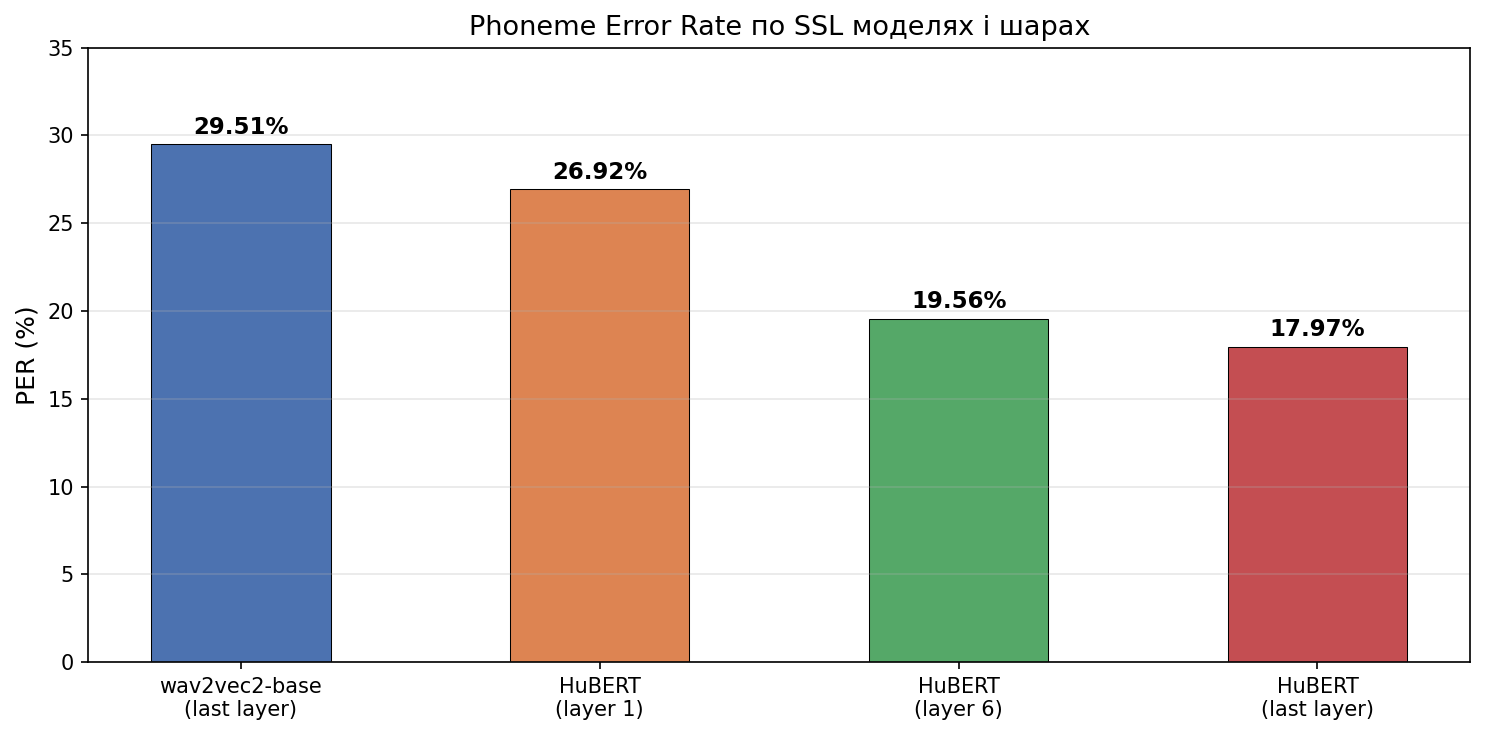

In [17]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

fig, ax = plt.subplots(figsize=(10, 5))

models = ['wav2vec2-base\n(last layer)', 'HuBERT\n(layer 1)', 'HuBERT\n(layer 6)', 'HuBERT\n(last layer)']
pers = [29.51, 26.92, 19.56, 17.97]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

bars = ax.bar(models, pers, color=colors, width=0.5, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, pers):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('PER (%)', fontsize=12)
ax.set_title('Phoneme Error Rate по SSL моделях і шарах', fontsize=13)
ax.set_ylim(0, 35)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/timit_per_comparison.png', bbox_inches='tight')
plt.show()

 Графік 2: Loss криві тренування

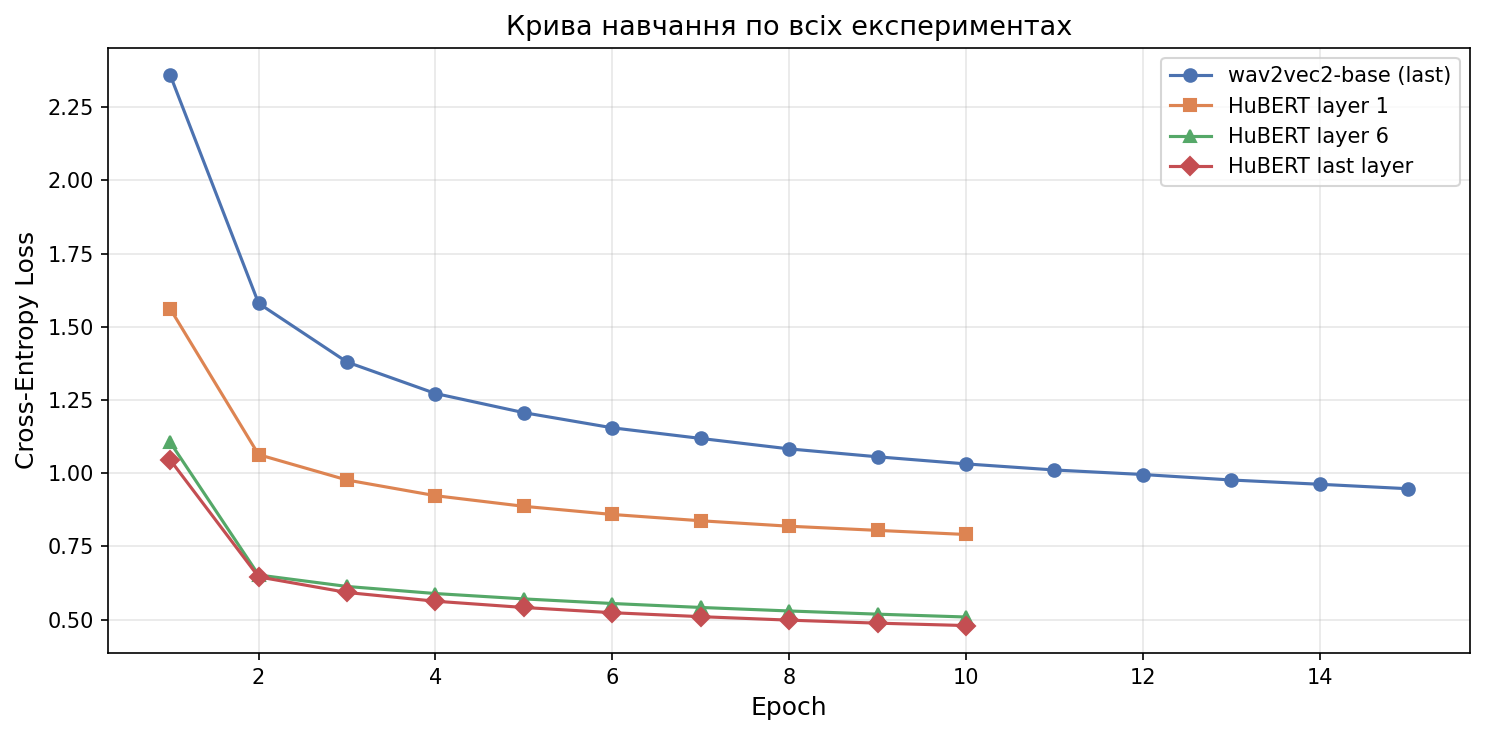

In [18]:
epochs = list(range(1, 16))
wav2vec2_losses = [2.3595, 1.5800, 1.3795, 1.2721, 1.2067,
                   1.1550, 1.1187, 1.0830, 1.0560, 1.0317,
                   1.0110, 0.9955, 0.9768, 0.9622, 0.9470]

epochs10 = list(range(1, 11))
hubert_last_losses = [1.0454, 0.6460, 0.5927, 0.5629, 0.5415,
                      0.5237, 0.5102, 0.4983, 0.4880, 0.4798]
hubert_l6_losses   = [1.1054, 0.6524, 0.6133, 0.5891, 0.5708,
                      0.5551, 0.5416, 0.5296, 0.5187, 0.5090]
hubert_l1_losses   = [1.5615, 1.0634, 0.9767, 0.9232, 0.8869,
                      0.8591, 0.8376, 0.8190, 0.8048, 0.7907]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs,   wav2vec2_losses,  'o-', label='wav2vec2-base (last)', color='#4C72B0')
ax.plot(epochs10, hubert_l1_losses, 's-', label='HuBERT layer 1',      color='#DD8452')
ax.plot(epochs10, hubert_l6_losses, '^-', label='HuBERT layer 6',      color='#55A868')
ax.plot(epochs10, hubert_last_losses,'D-',label='HuBERT last layer',   color='#C44E52')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('Крива навчання по всіх експериментах', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/timit_loss_curves.png', bbox_inches='tight')
plt.show()

Графік 3: PER по шарах HuBERT

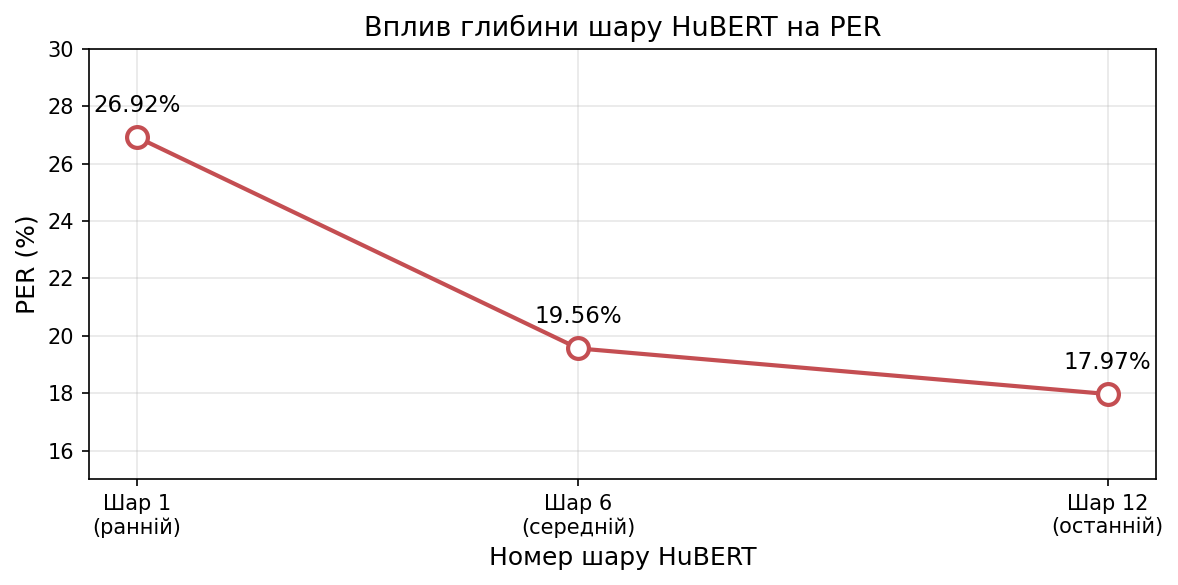

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))

layers = [1, 6, 12]
hubert_pers = [26.92, 19.56, 17.97]

ax.plot(layers, hubert_pers, 'o-', color='#C44E52', linewidth=2,
        markersize=10, markerfacecolor='white', markeredgewidth=2)
for x, y in zip(layers, hubert_pers):
    ax.annotate(f'{y:.2f}%', (x, y), textcoords="offset points",
                xytext=(0, 12), ha='center', fontsize=11)

ax.set_xlabel('Номер шару HuBERT', fontsize=12)
ax.set_ylabel('PER (%)', fontsize=12)
ax.set_title('Вплив глибини шару HuBERT на PER', fontsize=13)
ax.set_xticks([1, 6, 12])
ax.set_xticklabels(['Шар 1\n(ранній)', 'Шар 6\n(середній)', 'Шар 12\n(останній)'])
ax.set_ylim(15, 30)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/timit_hubert_layers.png', bbox_inches='tight')
plt.show()